# Project 00 · Solutions (answer key)

Open this notebook only after you have tried the tasks. Every **Check** cell passes with this code. Your own code may look different and still be correct. This notebook was run from top to bottom, so its outputs are what you should see.

Run it from the `solutions/` folder. It reads the data from `../data/` and writes its own `trading_tools.py` and `output/` folder here, so the student notebook is not affected.

## Part 0 · Setup

**Lecture 00:** *Python environments*, *Modules*

Lecture 00 introduced the Python interpreter, Jupyter, and IPython. `python --version` in a terminal shows the version of Python that runs your code. The cell below prints the version, checks that the libraries load, and checks that the data file is where the notebook expects it. Lines that start with `%` (such as `%matplotlib inline`) are **IPython magics**: commands for the notebook itself, not Python code.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

PRICE_FILE = "../data/prices.csv"       # simulated prices, one row per trading day

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Working folder:", os.getcwd())

assert os.path.exists(PRICE_FILE), "Cannot find " + PRICE_FILE + ". Open this notebook from the project folder."
print("✅ Setup OK")

Python: 3.11.2
NumPy: 2.4.6
Working folder: /home/user/Algorithmic_Trading_with_Python/Project 00_Python Basics Trading Lab/solutions
✅ Setup OK


## Part 1 · Variables and types

**Lecture 00:** *Variables and types*, *Fundamental types*, *Type casting*

A variable is a name that refers to a value, set with `=`. Python decides the type from the value: `int` (whole number), `float` (decimal), `str` (text), or `bool` (`True` / `False`). Check a type with `type()` or `isinstance()`. Names can contain letters, digits, and underscores, but cannot start with a digit. Convert with `int()`, `float()`, `str()`, or `bool()`.

### Task 1.1 · Describe one position
Replace each `...` with the value given in its comment.

In [2]:
# Task 1.1: replace each ... with the value named in its comment
ticker = "AAA"               # text
shares = 10                  # whole number
price = 101.25               # decimal number
is_market_open = False       # True or False
cash = 10000.0               # decimal number

In [3]:
assert ticker == "AAA", 'ticker should be the text "AAA" (with quotes)'
assert type(shares) is int and shares == 10, "shares should be the whole number 10 (no decimal point)"
assert type(price) is float and price == 101.25, "price should be the decimal number 101.25"
assert type(is_market_open) is bool and is_market_open is False, "is_market_open should be False"
assert type(cash) is float and cash == 10000.0, "cash should be the decimal number 10000.0"
print("✅ Task 1.1 passed")

✅ Task 1.1 passed


### Task 1.2 · Convert a float to an int
In Python 3, `/` always gives a float, even when the answer is whole. Convert the value to an `int`.

<details><summary><b>💡 Hint</b></summary>

`int(x)` turns a number into a whole number. It cuts off the decimal part.

</details>

In [4]:
budget = 1000.0
unit_price = 100.0
n_shares_float = budget / unit_price          # division gives a float: 10.0
print(n_shares_float, type(n_shares_float))

# Task 1.2: create n_shares, an int with the same value as n_shares_float
n_shares = int(n_shares_float)

10.0 <class 'float'>


In [5]:
assert type(n_shares) is int and n_shares == 10, "n_shares should be the int 10. Try int(...)"
print("✅ Task 1.2 passed")

✅ Task 1.2 passed


### Task 1.3 · Convert text from a data feed
A price feed sends prices as text. Convert the text to a float. `str()` does the reverse and turns a number into text.

In [6]:
price_text = "187.25"                         # the feed sends text
# Task 1.3: create feed_price, a float with the value of price_text
feed_price = float(price_text)

# Task 1.3b: str() turns a number into text. Create shares_text, the text "10" (made from shares).
shares_text = str(shares)
print(isinstance(feed_price, float), repr(shares_text))

True '10'


In [7]:
assert type(feed_price) is float and feed_price == 187.25, "feed_price should be the float 187.25"
assert shares_text == "10" and isinstance(shares_text, str), "shares_text should be the text \"10\". Try str(shares)."
print("✅ Task 1.3 passed")

✅ Task 1.3 passed


### Bonus · Complex numbers (optional)
Lecture 00 also covers complex numbers. You will not need them in this project. Run the cell and read the output. In Part 10 you will see what happens when you call `float(z)`.

In [8]:
z = 1.0 - 1.0j                  # the letter j marks the imaginary part
print(type(z), z.real, z.imag)
print("bool(z.real) =", bool(z.real), "| bool(0.0) =", bool(0.0))

<class 'complex'> 1.0 -1.0
bool(z.real) = True | bool(0.0) = False


## Part 2 · Operators and comparisons

**Lecture 00:** *Operators and comparisons*

- Arithmetic: `+ - * /` (true division), `//` (integer division), `**` (power)
- Logic: `and`, `or`, `not`
- Comparison: `==`, `!=`, `<`, `>`, `<=`, `>=`. `==` compares values. `is` checks whether two names refer to the same object.

### Task 2.1 · Position value and cost
Use `shares`, `price`, and `cash` from Part 1 and the fee below.

In [9]:
fee = 1.0                                     # commission per trade, in dollars
# Task 2.1: calculate the three values
position_value = shares * price             # shares times price
total_cost = position_value + fee           # position value plus the fee
cash_after_buy = cash - total_cost         # cash left after paying total_cost

In [10]:
assert abs(position_value - 1012.5) < 1e-9, "position_value should be shares * price = 1012.5"
assert abs(total_cost - 1013.5) < 1e-9, "total_cost should be position_value + fee = 1013.5"
assert abs(cash_after_buy - 8986.5) < 1e-9, "cash_after_buy should be cash - total_cost = 8986.5"
print("✅ Task 2.1 passed")

✅ Task 2.1 passed


### Task 2.2 · Whole shares and leftover cash
How many whole shares fit in `budget` at `price`? Use `//` (integer division) and wrap the result in `int()`. Then work out the cash left over.

<details><summary><b>💡 Hint</b></summary>

`budget // price` gives the number of whole shares as a float (for example `9.0`). `int()` makes it a whole number. The leftover is `budget - max_shares * price`.

</details>

In [11]:
budget = 1000.0
# Task 2.2
max_shares = int(budget // price)               # whole shares that fit in the budget
leftover = budget - max_shares * price          # cash left over after buying max_shares

In [12]:
assert type(max_shares) is int and max_shares == 9, "max_shares should be the int 9 (use // and int)"
assert abs(leftover - 88.75) < 1e-9, "leftover should be budget - max_shares * price = 88.75"
print("✅ Task 2.2 passed")

✅ Task 2.2 passed


### Task 2.3 · Compound growth
An account of 10,000 dollars grows 8% a year. After `years` years its value is `start * (1 + rate) ** years`.

In [13]:
# Task 2.3
value_after_5_years = 10000.0 * (1 + 0.08) ** 5
print(round(value_after_5_years, 2))

14693.28


In [14]:
assert abs(value_after_5_years - 14693.28) < 0.01, "expected about 14693.28"
print("✅ Task 2.3 passed")

✅ Task 2.3 passed


### Task 2.4 · Logic with `and`, `or`, and `not`
Remember that `is_market_open` is `False`.

In [15]:
# Task 2.4
can_buy = is_market_open and total_cost <= cash     # True only if the market is open AND we can pay
must_wait = not can_buy                              # True when we cannot buy
has_option = can_buy or cash >= 1000                 # True if we can buy OR have at least 1000 in cash
print(can_buy, must_wait, has_option)

False True True


In [16]:
assert can_buy is False and must_wait is True and has_option is True, "Check your and / or / not logic"
print("✅ Task 2.4 passed")

✅ Task 2.4 passed


**Predict first:** before you run the cell, what does each line print? Then run it to check.

In [17]:
a = [1, 2]
b = [1, 2]
c = a
print("a == b:", a == b, "| a is b:", a is b)
print("a is c:", a is c)

a == b: True | a is b: False
a is c: True


## Part 3 · Strings

**Lecture 00:** *Strings*, *String formatting examples*

- A string is a sequence. `s[0]` is the first character, and `s[start:stop]` is a **slice** (`stop` is not included). `s[::2]` takes every second character. `len(s)` counts the characters.
- `s.replace(old, new)` returns a new string. Strings never change in place.
- `%` formatting and `.format()` both build text. `%s` is text, `%d` is a whole number, and `%.2f` is a decimal with 2 places.

### Task 3.1 · Slicing a ticker code

In [18]:
exchange_code = "NASDAQ:AAA"
# Task 3.1
first_char = exchange_code[0]                 # the first character: N
symbol = exchange_code[7:]                    # the part after the colon: AAA
exchange = exchange_code[:6]                  # the part before the colon: NASDAQ
dotted = exchange_code.replace(":", ".")      # NASDAQ.AAA
n_chars = len(exchange_code)                  # how many characters, counting the colon
print(exchange_code[::2])                       # a step of 2 takes every second character (given)

NSA:A


In [19]:
assert first_char == "N", "first_char should be the first character, exchange_code[0]"
assert symbol == "AAA" and exchange == "NASDAQ" and dotted == "NASDAQ.AAA", "Check your slices and replace()"
assert n_chars == 10, "len() counts every character, colon included: NASDAQ:AAA has 10"
print("✅ Task 3.1 passed")

✅ Task 3.1 passed


### Task 3.2 · Cleaning a price that is written as text
Some websites show prices like `"$1,234.50"`. Remove the `$` and the comma, then convert to a float.

In [20]:
raw_price = "$1,234.50"
# Task 3.2
clean_price = float(raw_price.replace("$", "").replace(",", ""))

In [21]:
assert type(clean_price) is float and clean_price == 1234.5, "clean_price should be the float 1234.5"
print("✅ Task 3.2 passed")

✅ Task 3.2 passed


### Task 3.3 · Slicing dates
Dates are written as `YYYY-MM-DD`. Slice out the year, the month, and the day. They stay as text.

In [22]:
trade_date = "2025-03-14"
# Task 3.3
trade_year = trade_date[:4]                  # "2025"
trade_month = trade_date[5:7]                # "03"
trade_day = trade_date[8:]                   # "14"

In [23]:
assert trade_year == "2025" and trade_month == "03" and trade_day == "14", "Check your slices of trade_date"
assert int(trade_month) == 3, "trade_month is text. int() turns it into a number"
print("✅ Task 3.3 passed")

✅ Task 3.3 passed


### Task 3.4 · Formatting a trade confirmation
Build the same confirmation two ways. Target text: `BUY 10 AAA @ 101.25 = 1012.50`

<details><summary><b>💡 Hint</b></summary>

- `%`: `"%s %d %s @ %.2f = %.2f" % (...)` fills the placeholders in order.
- `.format()`: `"{0} {1} {2} ...".format(...)` fills `{0}`, `{1}`, and so on. `{3:.2f}` gives 2 decimals.

</details>

In [24]:
# Task 3.4a: with % formatting (%s = text, %d = whole number, %.2f = 2 decimals)
msg_percent = "%s %d %s @ %.2f = %.2f" % ("BUY", shares, ticker, price, position_value)

# Task 3.4b: with .format() ({0}, {1}, ... refer to the arguments in order)
msg_format = "{0} {1} {2} @ {3:.2f} = {4:.2f}".format("BUY", shares, ticker, price, position_value)

# Bonus: f-strings do the same job. You will often see them in modern code.
msg_fstring = f"BUY {shares} {ticker} @ {price:.2f} = {position_value:.2f}"
print(msg_percent)
print(msg_format)
print(msg_fstring)

BUY 10 AAA @ 101.25 = 1012.50
BUY 10 AAA @ 101.25 = 1012.50
BUY 10 AAA @ 101.25 = 1012.50


In [25]:
target = "BUY 10 AAA @ 101.25 = 1012.50"
assert msg_percent == target, "msg_percent should read: " + target
assert msg_format == target, "msg_format should read: " + target
print("✅ Task 3.4 passed")

✅ Task 3.4 passed


## Part 4 · Lists

**Lecture 00:** *List*, *Adding, inserting, modifying, and removing elements*, `range`

Lists are **mutable**, so you can change them in place:
- `append(x)` adds `x` at the end
- `insert(i, x)` adds `x` at position `i`
- `remove(x)` deletes the first item equal to `x`
- `del lst[i]` deletes the item at position `i`

Indexes start at 0, and negative indexes count from the end. `lst.sort()` sorts the list in place, and `sorted(lst)` returns a new sorted list. A **nested** list is a list whose items are lists, read as `grid[row][col]`. `range(start, stop, step)` makes a sequence of whole numbers and does not include `stop`.

### Task 4.1 · Build and edit a list of closing prices

In [26]:
# Task 4.1a: create the list closes with these five closing prices, in this order:
#            100.0, 101.5, 99.8, 102.3, 103.0
closes = [100.0, 101.5, 99.8, 102.3, 103.0]

# Task 4.1b: make these four changes, in this order (one line each)
closes.append(104.1)          # 1. add 104.1 to the end
closes.insert(0, 99.0)        # 2. insert 99.0 at position 0
closes.remove(99.8)           # 3. remove the value 99.8
del closes[-1]                # 4. delete the last item
print(closes)

[99.0, 100.0, 101.5, 102.3, 103.0]


In [27]:
assert closes == [99.0, 100.0, 101.5, 102.3, 103.0], "after the four changes, closes should be [99.0, 100.0, 101.5, 102.3, 103.0]"
print("✅ Task 4.1 passed")

✅ Task 4.1 passed


### Task 4.2 · Slicing a list

<details><summary><b>💡 Hint</b></summary>

`lst[-3:]` gives the last three items. `lst[::2]` gives every second item, starting with the first.

</details>

In [28]:
# Task 4.2
last_three = closes[-3:]                      # the last three closes
every_other = closes[::2]                     # every second close, starting with the first
print(last_three, every_other)

[101.5, 102.3, 103.0] [99.0, 101.5, 103.0]


In [29]:
assert last_three == [101.5, 102.3, 103.0], "last_three should hold the last three closes"
assert every_other == [99.0, 101.5, 103.0], "every_other should be closes[::2]"
print("✅ Task 4.2 passed")

✅ Task 4.2 passed


### Task 4.3 · A mixed-type list and `range`

In [30]:
# Task 4.3a: a trade log is a list that mixes types: "BUY", the ticker, the shares, and the price
trade_log = ["BUY", ticker, shares, price]

# Task 4.3b: use list(range(...)) to make three lists
days = list(range(1, 6))               # 1, 2, 3, 4, 5
even_days = list(range(0, 10, 2))      # 0, 2, 4, 6, 8
countdown = list(range(5, 0, -1))      # 5, 4, 3, 2, 1
print(trade_log, days, even_days, countdown)

['BUY', 'AAA', 10, 101.25] [1, 2, 3, 4, 5] [0, 2, 4, 6, 8] [5, 4, 3, 2, 1]


In [31]:
assert trade_log == ["BUY", "AAA", 10, 101.25], "trade_log should be ['BUY', ticker, shares, price]"
assert days == [1, 2, 3, 4, 5] and even_days == [0, 2, 4, 6, 8] and countdown == [5, 4, 3, 2, 1], "Check your range() calls"
print("✅ Task 4.3 passed")

✅ Task 4.3 passed


### Task 4.4 · The watchlist
Later parts use this list of tickers. Its order must match the columns of the data file.

In [32]:
# Task 4.4: the three tickers, in the same order as the columns of the data file
TICKERS = ["AAA", "BBB", "CCC"]

In [33]:
assert TICKERS == ["AAA", "BBB", "CCC"], "TICKERS should be ['AAA', 'BBB', 'CCC']"
print("✅ Task 4.4 passed")

✅ Task 4.4 passed


### Task 4.5 · Sorting and nested lists

In [34]:
# Task 4.5a: sorted() returns a new sorted list and leaves closes unchanged. Sort closes from highest to lowest.
ranked = sorted(closes, reverse=True)

# Task 4.5b: a nested list is a list inside a list. Read the CCC price on day 2 (row 1, column 2) from price_grid.
price_grid = [[100.0, 50.0, 200.0], [101.0, 49.5, 201.0]]     # one row per day; columns are AAA, BBB, CCC
ccc_day2 = price_grid[1][2]
print(ranked, ccc_day2)

[103.0, 102.3, 101.5, 100.0, 99.0] 201.0


In [35]:
assert ranked == [103.0, 102.3, 101.5, 100.0, 99.0], "ranked should hold the closes from highest to lowest"
assert closes == [99.0, 100.0, 101.5, 102.3, 103.0], "sorted() should leave closes unchanged"
assert ccc_day2 == 201.0, "price_grid[1][2] is row 1 (day 2), column 2 (CCC)"
print("✅ Task 4.5 passed")

✅ Task 4.5 passed


## Part 5 · Tuples and dictionaries

**Lecture 00:** *Tuples*, *Dictionaries*

- A **tuple** is written `(a, b, c)`. It cannot be changed after you create it (it is **immutable**). You can **unpack** it into several variables: `x, y = point`.
- A **dictionary** maps keys to values, for example `{"AAA": 10}`. Read a value with `d["AAA"]`, set one with `d["BBB"] = 25`, and loop over pairs with `d.items()`. `d.get(key, default)` returns `default` when the key is missing.

### Task 5.1 · A trade record as a tuple

In [36]:
# Task 5.1a: build a tuple called trade with (ticker, "BUY", shares, price)
trade = (ticker, "BUY", shares, price)

# Task 5.1b: unpack the tuple into four variables
t_ticker, t_side, t_shares, t_price = trade
print(t_ticker, t_side, t_shares, t_price)

AAA BUY 10 101.25


In [37]:
assert trade == ("AAA", "BUY", 10, 101.25), "trade should be the tuple ('AAA', 'BUY', 10, 101.25)"
assert t_side == "BUY" and t_shares == 10, "the unpacked values are not right"
print("✅ Task 5.1 passed")

✅ Task 5.1 passed


### Task 5.2 · Strategy parameters in a dictionary
The names `short_window` and `long_window` match the parameters in Lecture 07. The backtest reads all its settings from this dictionary.

In [38]:
# Task 5.2: fill in the values
params = {
    "short_window": 10,          # days in the fast moving average
    "long_window": 30,           # days in the slow moving average
    "fee": 1.0,                  # dollars per trade
    "initial_cash": 10000.0,     # starting money for each stock
}
print("Days between the two averages:", params["long_window"] - params["short_window"])

Days between the two averages: 20


In [39]:
assert params == {"short_window": 10, "long_window": 30, "fee": 1.0, "initial_cash": 10000.0}, "Check the values in params"
print("✅ Task 5.2 passed")

✅ Task 5.2 passed


### Task 5.3 · Update a dictionary
Add a new key for 25 shares of BBB. Then change the AAA count to 15.

In [40]:
holdings = {"AAA": 10}                 # shares we own, by ticker
# Task 5.3
holdings["BBB"] = 25
holdings["AAA"] = 15
print(holdings)

{'AAA': 15, 'BBB': 25}


In [41]:
assert holdings == {"AAA": 15, "BBB": 25}, "holdings should be {'AAA': 15, 'BBB': 25}"
print("✅ Task 5.3 passed")

✅ Task 5.3 passed


## Part 6 · Conditional statements

**Lecture 00:** *Conditional statements (`if`, `elif`, `else`)*, *Program blocks are defined by their indentation*

`if` runs its block only when the condition is `True`. `elif` means "otherwise, if", and `else` catches everything left over. Blocks are defined by indentation (4 spaces). A line with the wrong indentation causes an `IndentationError`.

### Task 6.1 · Label a day's return

In [42]:
r = 0.025                     # today's return: +2.5%
label = None
# Task 6.1: write an if / elif / else block that sets label
#   r >= 0.02  -> "big gain"
#   r > 0      -> "gain"
#   r == 0     -> "flat"
#   otherwise  -> "loss"
if r >= 0.02:
    label = "big gain"
elif r > 0:
    label = "gain"
elif r == 0:
    label = "flat"
else:
    label = "loss"
print(label)

big gain


In [43]:
assert label == "big gain", "With r = 0.025 the label should be 'big gain'. Change r to test the other branches."
print("✅ Task 6.1 passed")

✅ Task 6.1 passed


### Task 6.2 · Turn two averages into a signal
If the fast average is above the slow average, the signal is `"BUY"`. If it is below, the signal is `"SELL"`. Otherwise it is `"HOLD"`.

In [44]:
short_sma = 101.0          # fast average today
long_sma = 99.5            # slow average today
# Task 6.2
if short_sma > long_sma:
    signal = "BUY"
elif short_sma < long_sma:
    signal = "SELL"
else:
    signal = "HOLD"
print(signal)

BUY


In [45]:
assert signal == "BUY", "with short_sma 101.0 and long_sma 99.5 the signal should be 'BUY'"
print("✅ Task 6.2 passed")

✅ Task 6.2 passed


### Task 6.3 · Fix the indentation
The cell below has an indentation error. Fix it so that `message` gets the text. Do not change the text.

In [46]:
shares_held = 0
message = None
if shares_held == 0:
    message = "No position: waiting for a BUY signal."
print(message)

No position: waiting for a BUY signal.


In [47]:
assert message == "No position: waiting for a BUY signal.", "Indent the message line so it sits inside the if block"
print("✅ Task 6.3 passed")

✅ Task 6.3 passed


## Part 7 · Loops

**Lecture 00:** *`for` loops*, *`enumerate`*, *`while` loops*, *List comprehensions*

- `for item in collection:` runs its block once per item. To loop over a dictionary, use `.items()`, which gives the key and the value.
- `enumerate(lst)` gives the index and the item together.
- `while condition:` repeats while the condition is `True`. Make sure the loop can stop.
- `[expression for item in collection]` builds a list in one line.

### Task 7.1 · Loop over a dictionary

In [48]:
# holdings is {"AAA": 15, "BBB": 25} from Part 5
lines = []
# Task 7.1: for each ticker and share count, append text such as "AAA: 15 shares"
for ticker_name, n in holdings.items():
    lines.append("%s: %d shares" % (ticker_name, n))
print(lines)

['AAA: 15 shares', 'BBB: 25 shares']


In [49]:
assert lines == ["AAA: 15 shares", "BBB: 25 shares"], "lines should hold one text line per ticker"
print("✅ Task 7.1 passed")

✅ Task 7.1 passed


### Task 7.2 · `while` and `enumerate`
Use `closes` from Part 4: `[99.0, 100.0, 101.5, 102.3, 103.0]`.

<details><summary><b>💡 Hint</b></summary>

- The `while` condition needs two parts joined with `and`. First, `i` must still be inside the list (`i < len(closes)`). Second, the close at `i` must not yet be above 101.0.
- `for day, close in enumerate(closes):` gives you `day` (the index) and `close` (the value) on each pass.

</details>

In [50]:
# Task 7.2a: use a while loop to find the index of the first close above 101.0.
#            Keep going while i is still inside the list AND the close at i is not above 101.0.
i = 0
while i < len(closes) and closes[i] <= 101.0:
    i += 1
first_above_101 = i
print("first close above 101.0 is at index", first_above_101)

# Task 7.2b: use enumerate to collect the index of each close above 102.0
days_above_102 = []
for day, close in enumerate(closes):
    if close > 102.0:
        days_above_102.append(day)
print("days above 102.0:", days_above_102)

first close above 101.0 is at index 2
days above 102.0: [3, 4]


In [51]:
assert first_above_101 == 2, "first_above_101 should be 2 (the close 101.5 is at index 2)"
assert days_above_102 == [3, 4], "days_above_102 should be [3, 4]"
print("✅ Task 7.2 passed")

✅ Task 7.2 passed


### Task 7.3 · A list comprehension for daily returns
Daily return = today's close / yesterday's close − 1, for every day after the first. Write one list comprehension using `range(1, len(closes))`.

In [52]:
# Task 7.3
daily_rets = [closes[t] / closes[t - 1] - 1 for t in range(1, len(closes))]
print([round(x, 4) for x in daily_rets])

[0.0101, 0.015, 0.0079, 0.0068]


In [53]:
assert len(daily_rets) == 4, "there are 4 daily returns for 5 closes"
assert abs(daily_rets[0] - (100.0 / 99.0 - 1)) < 1e-12, "the first return should be 100 / 99 - 1"
print("✅ Task 7.3 passed")

✅ Task 7.3 passed


## Part 8 · Functions

**Lecture 00:** *Functions*, *Default argument and keyword arguments*, *Unnamed functions (`lambda`)*

- Define a function with `def name(arguments):`. Put a **docstring** (a short description) on the first line of the body. `help(name)` shows it.
- `return` sends a value back. A function with no `return` gives `None`.
- A **default argument** such as `fee=1.0` can be left out when you call the function. A **keyword argument** such as `fee=0.0` can be given in any order.
- `lambda x: ...` makes a small unnamed function. `map(function, items)` applies a function to every item.

### Task 8.1 · Daily returns as a function

In [54]:
def daily_returns(prices):
    """Return the list of simple daily returns: prices[t] / prices[t - 1] - 1."""
    # Task 8.1: return a list comprehension, as in Task 7.3
    return [prices[t] / prices[t - 1] - 1 for t in range(1, len(prices))]

In [55]:
_rets = daily_returns(closes)
assert isinstance(_rets, list), "daily_returns should return a list. Did you forget the return statement?"
assert len(_rets) == 4 and abs(_rets[0] - daily_rets[0]) < 1e-12, "daily_returns(closes) should give the same numbers as Task 7.3"
print("✅ Task 8.1 passed")

✅ Task 8.1 passed


### Task 8.2 · Total return

In [56]:
def total_return(start_value, end_value):
    """Return the decimal return from start_value to end_value (0.10 means +10%)."""
    # Task 8.2
    return end_value / start_value - 1

In [57]:
assert abs(total_return(100.0, 110.0) - 0.10) < 1e-12, "total_return(100, 110) should be 0.10"
assert abs(total_return(10000.0, 9000.0) + 0.10) < 1e-12, "total_return(10000, 9000) should be -0.10"
print("✅ Task 8.2 passed")

✅ Task 8.2 passed


### Task 8.3 · Position size with a default argument
Return the number of whole shares you can buy with `cash` at `price`, after paying `fee`.

<details><summary><b>💡 Hint</b></summary>

Subtract the fee first, then use `//` to find how many shares fit, then wrap it in `int()`.

</details>

In [58]:
def position_size(cash, price, fee=1.0):
    """Return how many whole shares you can buy with `cash` at `price`, after paying `fee`."""
    # Task 8.3
    return int((cash - fee) // price)

In [59]:
assert position_size(1000.0, 101.25) == 9, "position_size(1000, 101.25) should be 9 with the default fee"
assert position_size(cash=10000.0, price=100.0, fee=0.0) == 100, "position_size(cash=10000, price=100, fee=0) should be 100"
assert position_size(101.25, 101.25) == 0, "you cannot afford a share once the fee is paid"
print("✅ Task 8.3 passed")

✅ Task 8.3 passed


### Task 8.4 · Maximum drawdown with a loop
On each day, the **drawdown** is `value / peak − 1`. The peak is the highest value so far. The maximum drawdown is the most negative drawdown.

<details><summary><b>💡 Hint</b></summary>

Start with `peak = values[0]` and `worst = 0.0`. In the loop, update `peak` if `v` is higher. Then compare the drawdown of `v` with `worst`.

</details>

In [60]:
def max_drawdown(values):
    """Return the worst fall from a previous peak, as a negative decimal (-0.25 means -25%).
    Return 0.0 if the values never fall."""
    # Task 8.4: loop over values. Track the peak (highest value so far) and the worst drawdown.
    peak = values[0]
    worst = 0.0
    for v in values:
        if v > peak:
            peak = v
        drawdown = v / peak - 1
        if drawdown < worst:
            worst = drawdown
    return worst

In [61]:
assert abs(max_drawdown([100.0, 120.0, 90.0, 110.0]) - (90.0 / 120.0 - 1)) < 1e-12, "[100, 120, 90, 110] should give -0.25"
assert max_drawdown([1.0, 2.0, 3.0]) == 0.0, "a series that only rises has a drawdown of 0.0"
print("✅ Task 8.4 passed")

✅ Task 8.4 passed


### Task 8.5 · Simple moving average
For each day `i`, average the last `window` prices (days `i - window + 1` to `i`). Until there are enough prices, use `float("nan")` (not a number).

<details><summary><b>💡 Hint</b></summary>

`prices[i - window + 1 : i + 1]` is the slice for the last `window` days. `sum(...) / window` is its average. Use `if i < window - 1:` for the days with too few prices.

</details>

In [62]:
def simple_moving_average(prices, window):
    """Return a list the same length as prices. Item i is the average of the last `window` prices,
    or NaN while there are fewer than `window` prices."""
    # Task 8.5: loop over the day index i, then average the slice prices[i - window + 1 : i + 1]
    result = []
    for i in range(len(prices)):
        if i < window - 1:
            result.append(float("nan"))
        else:
            result.append(sum(prices[i - window + 1: i + 1]) / window)
    return result

In [63]:
_sma = simple_moving_average([1.0, 2.0, 3.0, 4.0, 5.0], 3)
assert isinstance(_sma, list) and len(_sma) == 5, "the result should be a list with one item per price"
assert np.isnan(_sma[0]) and np.isnan(_sma[1]), "the first two values should be NaN (not enough prices yet)"
assert _sma[2:] == [2.0, 3.0, 4.0], "the averages of the last 3 prices should be 2.0, 3.0, 4.0"
print("✅ Task 8.5 passed")

✅ Task 8.5 passed


### Task 8.6 · `lambda` and `map`

In [64]:
# Task 8.6a: to_percent is a lambda that turns a decimal return into text with 2 decimals and a % sign.
#            Example: 0.015 becomes "1.50%".   Hint: "%.2f%%" % (100 * r)
to_percent = lambda r: "%.2f%%" % (100 * r)

# Task 8.6b: apply to_percent to every daily return with map(). Wrap the result in list().
percent_text = list(map(to_percent, daily_rets))
print(percent_text)

['1.01%', '1.50%', '0.79%', '0.68%']


In [65]:
assert to_percent(0.015) == "1.50%", "to_percent(0.015) should be '1.50%'"
assert percent_text == [to_percent(r) for r in daily_rets], "percent_text should hold one text per daily return"
print("✅ Task 8.6 passed")

✅ Task 8.6 passed


### Task 8.7 · Returning several values
A function can return a tuple, so that the caller gets two values at once. Write `price_range(prices)` so that it returns `(lowest, highest)`.

In [66]:
def price_range(prices):
    """Return (lowest, highest) for a list of prices."""
    # Task 8.7
    return min(prices), max(prices)

low, high = price_range(closes)
print("low:", low, "| high:", high)

low: 99.0 | high: 103.0


In [67]:
assert (low, high) == (99.0, 103.0), "price_range(closes) should give (99.0, 103.0)"
print("✅ Task 8.7 passed")

✅ Task 8.7 passed


## Part 9 · Classes

**Lecture 00:** *Classes*

A **class** groups data (attributes such as `self.cash`) with the actions that work on that data (methods). `__init__` runs when you create an object. Each method's first parameter is `self`, which means "this object". `__str__` decides what `print()` shows.

The complete `Portfolio` class is below. Part 10 adds the order checks to `buy` and the `sell` method, so this cell already includes them.

In [68]:
class Portfolio:
    """A cash account that holds shares. Methods change the account; prices are passed in."""

    def __init__(self, starting_cash):
        self.cash = starting_cash       # money not yet invested
        self.holdings = {}              # ticker -> number of shares owned
        self.trade_log = []             # one (ticker, side, shares, price, fee) tuple per trade

    def __str__(self):
        # Task 9.1: return text such as "Cash: 8986.50 | Holdings: {'AAA': 10}"
        #           Hint: "%.2f" % self.cash formats the cash with 2 decimals.
        return "Cash: %.2f | Holdings: %s" % (self.cash, self.holdings)

    def total_value(self, prices):
        """Return cash plus the market value of every holding. `prices` maps ticker -> price."""
        # Task 9.2: start from self.cash, then add shares * prices[ticker] for each holding.
        #           Loop over self.holdings.items().
        value = self.cash
        for ticker, shares in self.holdings.items():
            value += shares * prices[ticker]
        return value

    def buy(self, ticker, price, shares, fee):
        """Buy `shares` of `ticker` at `price` and pay `fee`."""
        # Part 10 adds two checks here, before the account changes.
        if shares <= 0:
            raise ValueError("shares must be a positive whole number")
        if shares * price + fee > self.cash:
            raise ValueError("not enough cash to buy %d %s" % (shares, ticker))
        # Task 9.3: 1) subtract shares * price + fee from self.cash
        #           2) add shares to self.holdings (start from 0 if the ticker is new)
        #           3) append (ticker, "BUY", shares, price, fee) to self.trade_log
        self.cash -= shares * price + fee
        if ticker in self.holdings:
            self.holdings[ticker] += shares
        else:
            self.holdings[ticker] = shares
        self.trade_log.append((ticker, "BUY", shares, price, fee))

    def sell(self, ticker, price, shares, fee):
        """Sell `shares` of `ticker` at `price` and pay `fee`."""
        # Task 10.2: write sell() (see Task 10.2)
        if shares <= 0:
            raise ValueError("shares must be a positive whole number")
        owned = self.holdings.get(ticker, 0)
        if shares > owned:
            raise ValueError("cannot sell %d %s: you only own %d" % (shares, ticker, owned))
        self.cash += shares * price - fee
        self.holdings[ticker] -= shares
        if self.holdings[ticker] == 0:
            del self.holdings[ticker]
        self.trade_log.append((ticker, "SELL", shares, price, fee))

In [69]:
pf = Portfolio(10000.0)
assert pf.cash == 10000.0 and pf.holdings == {} and pf.trade_log == [], "the constructor should set cash, holdings and trade_log"
assert "10000.00" in str(pf), "__str__ should show the cash with 2 decimals, e.g. 'Cash: 10000.00 | ...'"

test = Portfolio(1000.0)
test.holdings["AAA"] = 10
assert abs(test.total_value({"AAA": 50.0}) - 1500.0) < 1e-9, "total_value should be cash + shares * price = 1500"

pf = Portfolio(10000.0)
pf.buy("AAA", 101.25, 10, 1.0)
assert abs(pf.cash - 8986.5) < 1e-9 and pf.holdings == {"AAA": 10}, "after buying 10 AAA at 101.25 with a 1.0 fee, cash should be 8986.5"
assert pf.trade_log == [("AAA", "BUY", 10, 101.25, 1.0)], "trade_log should record the trade as a tuple"
print("✅ Tasks 9.1–9.3 passed")

✅ Tasks 9.1–9.3 passed


## Part 10 · Exceptions

**Lecture 00:** *Exceptions*

An error **raises** an exception, which stops the normal flow. `try:` runs code that might fail, and `except SomeError as e:` handles the error. `else` runs only when no error happened, and `finally` always runs. Catch specific errors such as `ValueError` (a bad value) or `TypeError` (the wrong type), not a bare `except:`. `except Exception as e` catches almost any error, so use it with care.

You can also `raise` your own errors. In a trading system, a bad order should be refused, and the account should stay unchanged.

### Task 10.1 · Catch built-in errors
The first block is an example. The solution below follows its pattern for the next three.

In [70]:
caught = []                              # names of the exceptions we catch

try:
    print(not_defined_yet)               # this name does not exist, so NameError is raised
except NameError as e:
    caught.append(type(e).__name__)
    print("Caught:", e)

# Task 10.1a: a tuple cannot be changed. Try trade[2] = 20, catch TypeError, and add its name to caught.
try:
    trade[2] = 20
except TypeError as e:
    caught.append(type(e).__name__)
    print("Caught:", e)

# Task 10.1b: float("abc") raises ValueError. Catch it and add its name to caught.
try:
    float("abc")
except ValueError as e:
    caught.append(type(e).__name__)
    print("Caught:", e)

# Task 10.1c: 1 / 0 raises ZeroDivisionError. Catch ANY error with `except Exception as e`,
#             and add its name to caught.
try:
    1 / 0
except Exception as e:
    caught.append(type(e).__name__)
    print("Caught:", e)

Caught: name 'not_defined_yet' is not defined
Caught: 'tuple' object does not support item assignment
Caught: could not convert string to float: 'abc'
Caught: division by zero


In [71]:
assert caught == ["NameError", "TypeError", "ValueError", "ZeroDivisionError"], "caught should be ['NameError', 'TypeError', 'ValueError', 'ZeroDivisionError']"
print("✅ Task 10.1 passed")

✅ Task 10.1 passed


In [72]:
# Given: try / except / else / finally, run on two inputs
for text in ["12.5", "abc"]:
    try:
        value = float(text)
    except ValueError:
        print(repr(text), "is not a number")
    else:
        print(repr(text), "converted to", value)
    finally:
        print("done with", repr(text))

'12.5' converted to 12.5
done with '12.5'
'abc' is not a number
done with 'abc'


### Task 10.2 · Validate orders in `Portfolio`
The two checks in `buy()` and the `sell()` method are already in the class in Part 9. The check below tests that they work.

In [73]:
# Check 1: bad buy orders must raise ValueError and leave the account unchanged
pf = Portfolio(1000.0)
rejected = 0
for bad_order in [(101.25, 100, 1.0), (101.25, 0, 1.0)]:       # (price, shares, fee)
    try:
        pf.buy("AAA", bad_order[0], bad_order[1], bad_order[2])
    except ValueError:
        rejected += 1
assert rejected == 2, "buy() should raise ValueError for a too-expensive order and for 0 shares"
assert pf.cash == 1000.0 and pf.holdings == {}, "rejected orders must not change cash or holdings"

# Check 2: sell() works and refuses to sell more than you own
pf = Portfolio(10000.0)
pf.buy("AAA", 101.25, 10, 1.0)
pf.sell("AAA", 102.0, 4, 1.0)
assert pf.holdings == {"AAA": 6}, "after selling 4 of 10 shares, 6 should be left"
assert abs(pf.cash - 9393.5) < 1e-9, "cash should be 8986.5 + (4 * 102.0 - 1.0) = 9393.5"
assert pf.trade_log[-1] == ("AAA", "SELL", 4, 102.0, 1.0), "the sale should be logged as a tuple"
try:
    pf.sell("AAA", 102.0, 7, 1.0)                 # only 6 are left
    assert False, "selling more shares than you own should raise ValueError"
except ValueError:
    print("Selling 7 shares when only 6 are owned was rejected, as it should be.")
print("✅ Task 10.2 passed")

Selling 7 shares when only 6 are owned was rejected, as it should be.
✅ Task 10.2 passed


## Part 11 · Modules

**Lecture 00:** *Modules*, *Looking at what a module contains, and its documentation*

A **module** is a `.py` file: a plain-text Python program file in which each line is a statement, and lines that start with `#` are comments. `import name` loads it, and then you use `name.something`. Python includes a **standard library** of modules, such as `math` and `os`. Lecture 00 wrote its own module with the cell magic `%%file mymodule.py`. This project uses the same idea with `%%writefile`.

`dir(module)` lists the names in a module. `help(module.name)` shows a function's docstring. `from module import name` brings one name straight into your code, so you can call `name()` without the module prefix.

### Task 11.1 · Standard library: `math` and `os`

In [74]:
import math
import os

# Task 11.1a: annual_scale = math.sqrt(252). Multiplying daily volatility by it gives yearly volatility.
annual_scale = math.sqrt(252)
print("annual scale:", annual_scale)

# Task 11.1b: create a folder called output for saved results. exist_ok=True means no error if it exists.
os.makedirs("output", exist_ok=True)

# Task 11.1c: "from-import" brings one name straight into your code. Write: from math import sqrt
from math import sqrt
same_scale = sqrt(252)                 # the same value as annual_scale, without the math. prefix
print("same scale:", same_scale)

annual scale: 15.874507866387544
same scale: 15.874507866387544


In [75]:
assert abs(annual_scale - 15.8745) < 1e-3, "annual_scale should be math.sqrt(252), about 15.8745"
assert os.path.isdir("output"), "the output folder should exist"
assert "sqrt" in globals() and abs(same_scale - annual_scale) < 1e-12, "use from math import sqrt, then call sqrt(252)"
print("✅ Task 11.1 passed")

✅ Task 11.1 passed


### Task 11.2 · Build `trading_tools.py`
The cell below writes the module `trading_tools.py` into this folder. Running it again overwrites the file.

In [76]:
%%writefile trading_tools.py
"""trading_tools.py: helper functions and the Portfolio class for Project 00."""
import math


def daily_returns(prices):
    """Return the list of simple daily returns: prices[t] / prices[t - 1] - 1."""
    return [prices[t] / prices[t - 1] - 1 for t in range(1, len(prices))]


def total_return(start_value, end_value):
    """Return the decimal return from start_value to end_value (0.10 means +10%)."""
    return end_value / start_value - 1


def position_size(cash, price, fee=1.0):
    """Return how many whole shares you can buy with `cash` at `price`, after paying `fee`."""
    return int((cash - fee) // price)


def max_drawdown(values):
    """Return the worst fall from a previous peak, as a negative decimal (-0.25 means -25%)."""
    peak = values[0]
    worst = 0.0
    for v in values:
        if v > peak:
            peak = v
        drawdown = v / peak - 1
        if drawdown < worst:
            worst = drawdown
    return worst


def simple_moving_average(prices, window):
    """Return a list the same length as prices. Item i is the average of the last `window` prices, or NaN."""
    result = []
    for i in range(len(prices)):
        if i < window - 1:
            result.append(float("nan"))
        else:
            result.append(sum(prices[i - window + 1: i + 1]) / window)
    return result


def annualized_volatility(daily_rets):
    """Return the annualized volatility of daily returns: sample standard deviation * sqrt(252)."""
    n = len(daily_rets)
    mean = sum(daily_rets) / n
    variance = sum((r - mean) ** 2 for r in daily_rets) / (n - 1)
    return math.sqrt(variance) * math.sqrt(252)


class Portfolio:
    """A cash account that holds shares. Methods change the account; prices are passed in."""

    def __init__(self, starting_cash):
        self.cash = starting_cash
        self.holdings = {}
        self.trade_log = []

    def __str__(self):
        return "Cash: %.2f | Holdings: %s" % (self.cash, self.holdings)

    def total_value(self, prices):
        """Return cash plus the market value of every holding."""
        value = self.cash
        for ticker, shares in self.holdings.items():
            value += shares * prices[ticker]
        return value

    def buy(self, ticker, price, shares, fee):
        """Buy `shares` of `ticker` at `price` and pay `fee`."""
        if shares <= 0:
            raise ValueError("shares must be a positive whole number")
        if shares * price + fee > self.cash:
            raise ValueError("not enough cash to buy %d %s" % (shares, ticker))
        self.cash -= shares * price + fee
        if ticker in self.holdings:
            self.holdings[ticker] += shares
        else:
            self.holdings[ticker] = shares
        self.trade_log.append((ticker, "BUY", shares, price, fee))

    def sell(self, ticker, price, shares, fee):
        """Sell `shares` of `ticker` at `price` and pay `fee`."""
        if shares <= 0:
            raise ValueError("shares must be a positive whole number")
        owned = self.holdings.get(ticker, 0)
        if shares > owned:
            raise ValueError("cannot sell %d %s: you only own %d" % (shares, ticker, owned))
        self.cash += shares * price - fee
        self.holdings[ticker] -= shares
        if self.holdings[ticker] == 0:
            del self.holdings[ticker]
        self.trade_log.append((ticker, "SELL", shares, price, fee))

Writing trading_tools.py


In [77]:
import trading_tools as tt

print("Public names in trading_tools:", [name for name in dir(tt) if not name.startswith("_")])
assert abs(tt.total_return(100.0, 110.0) - 0.10) < 1e-12, "total_return is not working in the module"
assert tt.position_size(1000.0, 101.25) == 9, "position_size is not working in the module"
assert abs(tt.max_drawdown([100.0, 120.0, 90.0, 110.0]) - (90.0 / 120.0 - 1)) < 1e-12, "max_drawdown is not working in the module"
assert len(tt.simple_moving_average([1.0, 2.0, 3.0], 2)) == 3, "simple_moving_average should return one item per price"
assert len(tt.daily_returns([1.0, 2.0, 4.0])) == 2, "daily_returns should return one value per day after the first"
_rets = [0.01, -0.01, 0.02, -0.02]
_mean = sum(_rets) / len(_rets)
_sd = (sum((r - _mean) ** 2 for r in _rets) / (len(_rets) - 1)) ** 0.5
assert abs(tt.annualized_volatility(_rets) - _sd * 252 ** 0.5) < 1e-9, "annualized_volatility formula is off"
pf = tt.Portfolio(1000.0)
pf.buy("AAA", 10.0, 10, 0.0)
assert pf.holdings == {"AAA": 10} and abs(pf.cash - 900.0) < 1e-9, "tt.Portfolio does not behave like the Part 9 class"
print("✅ Task 11.2 passed")

Public names in trading_tools: ['Portfolio', 'annualized_volatility', 'daily_returns', 'math', 'max_drawdown', 'position_size', 'simple_moving_average', 'total_return']
✅ Task 11.2 passed


**Tips**
- `dir(tt)` lists the names in the module, and `help(tt.position_size)` shows the docstring.
- Keep your module code in the `%%writefile` cell. Running that cell rewrites `trading_tools.py`, so changes made directly to the file are lost, and so is any code not in the cell. After you change the cell and run it, choose **Kernel → Restart** so Python loads the new version. (Or run `importlib.reload(tt)`.)

In [78]:
help(tt.position_size)

Help on function position_size in module trading_tools:

position_size(cash, price, fee=1.0)
    Return how many whole shares you can buy with `cash` at `price`, after paying `fee`.



## Part 12 · NumPy arrays

**Lecture 00:** *NumPy: multidimensional data arrays*, *Creating NumPy arrays*, *More properties of the numpy arrays*

A NumPy **array** holds numbers of one type and works on every element at once (vectorized math). Inspect an array with `.shape` (rows and columns), `.size` (number of values), `.ndim` (number of dimensions), and `.dtype` (type of the values). Create arrays with `np.array(list)`, `np.arange`, `np.linspace`, `np.zeros`, `np.ones`, or random numbers from `np.random`. `.reshape(rows, cols)` changes the shape without changing the values.

### Task 12.1 · From a list to an array

In [79]:
# Task 12.1: convert the list closes to a NumPy array called closes_arr
closes_arr = np.array(closes)
print("shape:", closes_arr.shape, "| size:", closes_arr.size, "| ndim:", closes_arr.ndim, "| dtype:", closes_arr.dtype)

shape: (5,) | size: 5 | ndim: 1 | dtype: float64


In [80]:
assert isinstance(closes_arr, np.ndarray) and closes_arr.shape == (5,), "closes_arr should be a 1-D array with 5 values"
assert closes_arr.dtype == np.float64, "the values are decimals, so dtype should be float64"
print("✅ Task 12.1 passed")

✅ Task 12.1 passed


### Task 12.2 · Array generators

In [81]:
# Task 12.2
evens = np.arange(0, 10, 2)            # 0, 2, 4, 6, 8   (stop is not included)
grid = np.linspace(0, 1, 5)            # 0, 0.25, 0.5, 0.75, 1.0   (both ends included)
zero_matrix = np.zeros((2, 3))         # 2 rows and 3 columns of 0.0
ones_row = np.ones(4)                  # four 1.0 values
table = np.arange(6).reshape(2, 3)     # the numbers 0 to 5 arranged in 2 rows and 3 columns
print(evens, grid, zero_matrix, ones_row, table, sep="\n")

[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]
[[0. 0. 0.]
 [0. 0. 0.]]
[1. 1. 1. 1.]
[[0 1 2]
 [3 4 5]]


In [82]:
assert np.array_equal(evens, np.array([0, 2, 4, 6, 8])), "evens should be 0, 2, 4, 6, 8"
assert np.allclose(grid, [0, 0.25, 0.5, 0.75, 1.0]), "grid should be 5 evenly spaced values from 0 to 1"
assert zero_matrix.shape == (2, 3) and zero_matrix.sum() == 0, "zero_matrix should be 2 x 3 zeros"
assert np.array_equal(ones_row, np.ones(4)), "ones_row should be four 1.0 values"
assert table.shape == (2, 3) and table[1, 2] == 5, "table should be 2 x 3 with the numbers 0 to 5 in order (use reshape)"
print("✅ Task 12.2 passed")

✅ Task 12.2 passed


### Task 12.3 · Reproducible random numbers
`np.random.seed` makes the random numbers repeat exactly, so your results can be reproduced. The price path below starts at 100 and moves by about 1% a day.

In [83]:
np.random.seed(42)                       # the same seed gives the same random numbers every run
steps = np.random.randn(5)               # 5 standard-normal shocks
# Task 12.3: simulated = 100 times the cumulative product of (1 + 0.01 * steps)
simulated = 100 * np.cumprod(1 + 0.01 * steps)
print(np.round(simulated, 2))

[100.5  100.36 101.01 102.55 102.31]


In [84]:
np.random.seed(42)
_expected = 100 * np.cumprod(1 + 0.01 * np.random.randn(5))
assert np.allclose(simulated, _expected), "simulated should be 100 * np.cumprod(1 + 0.01 * steps)"
print("✅ Task 12.3 passed")

✅ Task 12.3 passed


### Task 12.4 · Changing the data type
Predict the result, then run it. What happens to 101.5 and 102.3?

In [85]:
# Task 12.4: convert closes_arr to whole numbers with astype(int)
closes_int = closes_arr.astype(int)
print(closes_int)

[ 99 100 101 102 103]


In [86]:
assert closes_int.tolist() == [99, 100, 101, 102, 103], "astype(int) cuts off the decimal part. It does not round."
print("✅ Task 12.4 passed")

✅ Task 12.4 passed


## Part 13 · File I/O

**Lecture 00:** *File I/O*, *Comma-separated values (CSV)*, *NumPy's native file format*

`np.genfromtxt(file, delimiter=",", skip_header=1)` reads a CSV file into an array. An empty cell becomes `nan` (not a number). `np.savetxt` writes a CSV file. `np.save` and `np.load` use NumPy's own `.npy` format, which keeps the exact values and types.

The file `data/prices.csv` has one row per trading day and the columns `date, AAA, BBB, CCC`. The cell below reads it. Run it and look at the output.

In [87]:
dates = np.genfromtxt(PRICE_FILE, delimiter=",", skip_header=1, usecols=0, dtype=str)
prices = np.genfromtxt(PRICE_FILE, delimiter=",", skip_header=1, usecols=(1, 2, 3))
print("prices shape:", prices.shape)
print("first dates:", dates[:3])
print(prices[:3])

prices shape: (252, 3)
first dates: ['2025-01-02' '2025-01-03' '2025-01-06']
[[100.    50.   200.  ]
 [ 99.92  51.22 198.31]
 [100.78  52.95 198.16]]


### Task 13.1 · Read the shape
`prices.shape` is `(number of days, number of tickers)`. Unpack it into two variables.

In [88]:
# Task 13.1
n_days, n_tickers = prices.shape
print(n_days, "days,", n_tickers, "tickers")

252 days, 3 tickers


In [89]:
assert n_days == 252 and n_tickers == 3, "prices should have 252 rows (days) and 3 columns (tickers)"
print("✅ Task 13.1 passed")

✅ Task 13.1 passed


### Task 13.2 · Find the missing value
`np.isnan(prices)` gives `True` where a value is missing. `np.where(mask)` returns the row and column numbers of every `True` value.

In [90]:
missing = np.isnan(prices)
# Task 13.2: use np.where on missing to get the row numbers and column numbers
rows, cols = np.where(missing)
print("missing at rows", rows, "and columns", cols)
print("date:", dates[rows[0]], "| ticker:", TICKERS[cols[0]])

missing at rows [58] and columns [1]
date: 2025-03-25 | ticker: BBB


In [91]:
assert len(rows) == 1 and cols[0] == 1, "there should be exactly one missing value, in column 1 (BBB)"
print("✅ Task 13.2 passed")

✅ Task 13.2 passed


### Task 13.3 · Fix it
Replace the missing value with the price from the day before, in the same column. Use the `rows` and `cols` arrays on both sides of the assignment.

<details><summary><b>💡 Hint</b></summary>

Indexing with two arrays selects several cells at once. `prices[rows, cols]` is the missing cells. `rows - 1` is the row before each one.

</details>

In [92]:
# Task 13.3: replace each missing value with the price from the day before
prices[rows, cols] = prices[rows - 1, cols]
print("missing values left:", int(np.isnan(prices).sum()))

missing values left: 0


In [93]:
assert not np.isnan(prices).any(), "there are still missing values in prices"
assert prices[58, 1] == prices[57, 1], "the filled value should equal the previous day's price"
print("✅ Task 13.3 passed")

✅ Task 13.3 passed


### Task 13.4 · Save and reload
Save the cleaned array with `np.save`, then load it back with `np.load`.

In [94]:
# Task 13.4a: save prices to output/prices_clean.npy
np.save("output/prices_clean.npy", prices)

# Task 13.4b: load the file back into reloaded
reloaded = np.load("output/prices_clean.npy")
print("identical after reload:", np.array_equal(prices, reloaded))

identical after reload: True


In [95]:
assert os.path.exists("output/prices_clean.npy"), "np.save should create output/prices_clean.npy"
assert np.array_equal(reloaded, prices), "reloaded should match prices exactly"
print("✅ Task 13.4 passed")

✅ Task 13.4 passed


## Part 14 · Array operations

**Lecture 00:** *Indexing*, *Index slicing*, *Fancy indexing*, *index masks*, *`where`*, *Scalar-array operations*, *Calculations with higher-dimensional data*, *Copy and deep copy*, *Vectorizing functions*, *Stacking and repeating arrays*, *Linear algebra*, *Data processing*, *Using arrays in conditions*

In `prices`, **rows are days** and **columns are tickers**, so `prices[day, ticker]` is one value. `axis=0` works down the rows (one result per ticker). `axis=1` works across the columns (one result per day).

Vectorized math such as `prices[1:] / prices[:-1]` replaces a loop, and it is faster and shorter. A **mask** is a True/False array made by a condition such as `returns < 0`.

### Task 14.1 · Indexing and slicing

In [96]:
# Task 14.1
bbb_last5 = prices[-5:, 1]                 # the last 5 closes of BBB (column 1)
first3_all = prices[:3, :]                 # the first 3 days for all tickers
aaa_column = prices[:, 0][:, np.newaxis]   # AAA as one column, shape (252, 1): np.newaxis adds an axis
print(bbb_last5, first3_all, aaa_column, sep="\n")

[29.07 29.53 28.39 27.79 27.22]
[[100.    50.   200.  ]
 [ 99.92  51.22 198.31]
 [100.78  52.95 198.16]]
[[100.  ]
 [ 99.92]
 [100.78]
 [ 99.18]
 [ 98.46]
 [ 98.37]
 [100.82]
 [102.45]
 [102.24]
 [103.15]
 [103.42]
 [102.23]
 [101.3 ]
 [100.12]
 [100.05]
 [100.25]
 [ 98.26]
 [ 99.48]
 [ 99.55]
 [ 99.39]
 [ 99.04]
 [100.87]
 [100.68]
 [100.5 ]
 [101.35]
 [101.37]
 [102.3 ]
 [102.43]
 [102.53]
 [103.96]
 [103.91]
 [102.88]
 [101.45]
 [101.54]
 [100.46]
 [101.34]
 [101.69]
 [101.36]
 [100.63]
 [100.58]
 [101.28]
 [102.29]
 [100.94]
 [103.17]
 [102.44]
 [101.11]
 [102.93]
 [104.38]
 [105.52]
 [104.75]
 [106.05]
 [105.94]
 [104.31]
 [103.55]
 [102.1 ]
 [103.18]
 [104.58]
 [103.39]
 [103.23]
 [103.72]
 [102.38]
 [103.5 ]
 [102.35]
 [100.78]
 [ 99.84]
 [ 99.45]
 [ 98.51]
 [ 99.89]
 [ 99.92]
 [ 98.34]
 [ 98.74]
 [ 97.18]
 [ 98.9 ]
 [ 97.59]
 [ 97.12]
 [ 97.36]
 [ 96.53]
 [ 95.48]
 [ 95.78]
 [ 94.12]
 [ 95.26]
 [ 93.9 ]
 [ 92.59]
 [ 92.47]
 [ 90.2 ]
 [ 90.2 ]
 [ 89.48]
 [ 89.84]
 [ 89.76]
 [ 90

In [97]:
assert bbb_last5.shape == (5,) and bbb_last5[-1] == prices[-1, 1], "bbb_last5 should hold the last 5 BBB prices"
assert first3_all.shape == (3, 3), "first3_all should have 3 rows and 3 columns"
assert aaa_column.shape == (n_days, 1), "aaa_column should have one column with one value per day (use [:, np.newaxis])"
print("✅ Task 14.1 passed")

✅ Task 14.1 passed


### Task 14.2 · Daily returns for all tickers at once
`returns[t] = prices[t + 1] / prices[t] - 1`. Use slices of the whole array and no loop.

In [98]:
# Task 14.2
returns = prices[1:] / prices[:-1] - 1
print("returns shape:", returns.shape)

returns shape: (251, 3)


In [99]:
assert returns.shape == (n_days - 1, 3), "returns should have one row fewer than prices"
assert np.allclose(returns[:, 0], tt.daily_returns(prices[:, 0].tolist())), "AAA returns should match your daily_returns function"
print("✅ Task 14.2 passed")

✅ Task 14.2 passed


### Task 14.3 · Masks: counting the days that match a condition
`(returns[:, 0] < 0)` is a mask of True/False values. `.sum()` counts the True values.

For the second count, `np.abs(returns) > 0.03` is a mask with one row per day and one column per ticker. `.any(axis=1)` asks "is there a True in this row?"

In [100]:
# Task 14.3a: how many days did AAA fall (return below 0)?
aaa_down_days = int((returns[:, 0] < 0).sum())

# Task 14.3b: how many days did at least one ticker move more than 3% in either direction?
big_move_days = int(np.any(np.abs(returns) > 0.03, axis=1).sum())
print("AAA down days:", aaa_down_days, "| days with a move over 3%:", big_move_days)

AAA down days: 130 | days with a move over 3%: 43


In [101]:
assert aaa_down_days == 130, "AAA fell on 130 days in this data. Check the mask (returns[:, 0] < 0)."
assert big_move_days == 43, "43 days had a move over 3% for at least one ticker. Check axis=1 and .any()."
print("✅ Task 14.3 passed")

✅ Task 14.3 passed


### Task 14.4 · Statistics along an axis
`axis=0` gives one value per column (ticker). For the standard deviation use `ddof=1`, the sample standard deviation. The module uses the same definition.

<details><summary><b>💡 Hint</b></summary>

`returns.std(axis=0, ddof=1)` gives one standard deviation per ticker. `returns.max(axis=0)` gives the best day for each ticker.

</details>

In [102]:
# Task 14.4: one value per ticker
avg_daily = returns.mean(axis=0)
vol_daily = returns.std(axis=0, ddof=1)
best_day = returns.max(axis=0)
worst_day = returns.min(axis=0)
print("average daily return (%):", np.round(avg_daily * 100, 4))
print("best day (%):", np.round(best_day * 100, 2))
print("worst day (%):", np.round(worst_day * 100, 2))

average daily return (%): [-0.0119 -0.2188 -0.0023]
best day (%): [2.73 6.59 4.17]
worst day (%): [-2.64 -5.26 -4.27]


In [103]:
assert avg_daily.shape == (3,) and np.allclose(avg_daily, [-1.19264e-04, -2.18823e-03, -2.29913e-05], atol=1e-8), "avg_daily should hold one mean per ticker (axis=0)"
assert np.allclose(vol_daily, [0.010783, 0.0215725, 0.0131412], atol=1e-6), "vol_daily should be the sample standard deviation (ddof=1) per ticker"
assert best_day.shape == (3,) and np.allclose(best_day, [0.0272582, 0.0658784, 0.0417318], atol=1e-6), "best_day should be the largest return for each ticker"
assert worst_day.shape == (3,) and np.allclose(worst_day, [-0.0264259, -0.0526316, -0.042669], atol=1e-6), "worst_day should be the smallest return for each ticker (use .min)"
print("✅ Task 14.4 passed")

✅ Task 14.4 passed


### Task 14.5 · Growth of one dollar
`np.cumprod(1 + returns, axis=0)` multiplies the daily growth factors one after another. `growth[t]` is the value of $1 invested at the start, on day `t`.

In [104]:
# Task 14.5a: np.cumprod(1 + returns, axis=0) multiplies the growth factors one after another.
growth = np.cumprod(1 + returns, axis=0)
final_multiple = growth[-1]            # the value of $1 at the end, one number per ticker
print("value of $1 at the end:", np.round(final_multiple, 4))

# Task 14.5b: np.cumsum adds up as it goes. Use it on AAA's daily returns (column 0) to get a running total.
running_sum = np.cumsum(returns[:, 0])
print("AAA running total of daily returns, last value:", round(running_sum[-1], 4))

value of $1 at the end: [0.9565 0.5444 0.973 ]
AAA running total of daily returns, last value: -0.0299


In [105]:
assert growth.shape == returns.shape, "growth should have the same shape as returns"
assert np.allclose(final_multiple, prices[-1] / prices[0]), "the value of $1 at the end should be last price / first price"
assert np.isclose(running_sum[-1], returns[:, 0].sum()), "the last running total should equal the sum of AAA's returns"
print("✅ Task 14.5 passed")

✅ Task 14.5 passed


### Task 14.6 · `where`: label each day
`np.where(condition, value_if_true, value_if_false)` works on a whole array at once.

In [106]:
# Task 14.6a: label each AAA day "up" if its return is above 0, otherwise "down"
aaa_labels = np.where(returns[:, 0] > 0, "up", "down")

# Task 14.6b: count the "up" days
up_days = int(np.sum(aaa_labels == "up"))
print("AAA up days:", up_days)

AAA up days: 120


In [107]:
assert len(aaa_labels) == n_days - 1, "there should be one label per daily return"
assert up_days == 120, "AAA rose on 120 days in this data. Check the np.where condition."
print("✅ Task 14.6 passed")

✅ Task 14.6 passed


### Task 14.7 · Copy vs view
A slice is a **view**. It shares memory with the original array, so changing the view also changes the original. Run the demo first. Then use `.copy()` in the task to get an independent array.

In [108]:
demo = prices.copy()             # a separate copy, so the real prices stay unchanged
view = demo[:3, 0]               # a view of the first 3 AAA prices
view[0] = 0.0
print("after changing the view, demo[0, 0] =", demo[0, 0])        # it changed!

# Task 14.7: make an independent copy of demo[:3, 0] and change the copy to 999.0
safe = demo[:3, 0].copy()
safe[0] = 999.0
print("after changing safe, demo[0, 0] =", demo[0, 0])            # this should not change

after changing the view, demo[0, 0] = 0.0
after changing safe, demo[0, 0] = 0.0


In [109]:
assert demo[0, 0] == 0.0, "changing safe must not change demo. Use .copy() to make a separate array."
assert safe[0] == 999.0, "safe should be the array you changed"
print("✅ Task 14.7 passed")

✅ Task 14.7 passed


### Task 14.8 · Vectorize a function
Your `if / elif / else` from Task 6.1 works on one number. `np.vectorize` turns a function like this into one that works on whole arrays.

In [110]:
def label_move(r):
    """Return 'big gain', 'gain', 'flat' or 'loss' for one daily return r."""
    # Task 14.8a: copy the if / elif / else logic from Task 6.1, but return the label
    if r >= 0.02:
        return "big gain"
    elif r > 0:
        return "gain"
    elif r == 0:
        return "flat"
    else:
        return "loss"

label_all = np.vectorize(label_move)      # now it works on whole arrays

# Task 14.8b: label the first 5 AAA daily returns with label_all
first5_labels = label_all(returns[:5, 0])
print(first5_labels)

['loss' 'gain' 'loss' 'loss' 'loss']


In [111]:
assert label_all(np.array([0.025, 0.01, 0.0, -0.01])).tolist() == ["big gain", "gain", "flat", "loss"], "label_move gives the wrong labels"
assert first5_labels.tolist() == ["loss", "gain", "loss", "loss", "loss"], "the first five AAA labels should be loss, gain, loss, loss, loss"
print("✅ Task 14.8 passed")

✅ Task 14.8 passed


### Task 14.9 · Stacking and joining
- `np.vstack((a, b))` stacks arrays one above the other (it adds rows).
- `np.hstack((a, b))` puts arrays side by side (it adds columns).
- `np.concatenate((a, b), axis=0)` is the general version. `axis=0` joins rows, and `axis=1` joins columns.

In [112]:
# Task 14.9a: stack the first 2 days and the last 2 days, one above the other
first_last = np.vstack((prices[:2], prices[-2:]))

# Task 14.9b: np.concatenate with axis=0 gives the same result as vstack. Build together the same way.
together = np.concatenate((prices[:2], prices[-2:]), axis=0)

# Task 14.9c: split the first 2 days into a one-column part (AAA) and a two-column part (BBB, CCC),
#             then join them side by side with hstack.
joined = np.hstack((prices[:2, :1], prices[:2, 1:]))
print(first_last, together, joined, sep="\n")

[[100.    50.   200.  ]
 [ 99.92  51.22 198.31]
 [ 96.77  27.79 195.87]
 [ 95.65  27.22 194.6 ]]
[[100.    50.   200.  ]
 [ 99.92  51.22 198.31]
 [ 96.77  27.79 195.87]
 [ 95.65  27.22 194.6 ]]
[[100.    50.   200.  ]
 [ 99.92  51.22 198.31]]


In [113]:
assert first_last.shape == (4, 3), "first_last should have 4 rows and 3 columns"
assert np.array_equal(first_last[2], prices[-2]), "row 3 of first_last should be the second-to-last day"
assert np.array_equal(together, first_last), "together should equal first_last (use concatenate with axis=0)"
assert np.array_equal(joined, prices[:2]), "joined should rebuild the first two days using hstack"
print("✅ Task 14.9 passed")

✅ Task 14.9 passed


### Task 14.10 · Repeat, tile, and resize
- `np.repeat(a, n)` repeats each item `n` times.
- `np.tile(a, n)` repeats the whole array `n` times.
- `np.resize(a, size)` makes an array of the given length by repeating the data.

In [114]:
# Task 14.10
steps_up = np.repeat(np.array([1.0, 2.0]), 2)               # each item twice: 1, 1, 2, 2
cycle = np.tile(np.array([1.0, 2.0]), 3)                    # the whole array three times: 1, 2, 1, 2, 1, 2
filled_len5 = np.resize(np.array([1.0, 2.0, 3.0]), 5)       # length 5, data repeated: 1, 2, 3, 1, 2
print(steps_up, cycle, filled_len5)

[1. 1. 2. 2.] [1. 2. 1. 2. 1. 2.] [1. 2. 3. 1. 2.]


In [115]:
assert np.array_equal(steps_up, [1, 1, 2, 2]), "np.repeat(a, 2) repeats each item twice"
assert np.array_equal(cycle, [1, 2, 1, 2, 1, 2]), "np.tile(a, 3) repeats the whole array three times"
assert np.array_equal(filled_len5, [1, 2, 3, 1, 2]), "np.resize(a, 5) makes an array of length 5 by repeating the data"
print("✅ Task 14.10 passed")

✅ Task 14.10 passed


### Task 14.11 · Summary statistics, conditions, and iteration
`.var()` is the variance (`ddof=1` gives the sample version, as in Task 14.4). `np.prod` multiplies all the values. `np.any` and `np.all` answer "is at least one True?" and "are all True?".

In [116]:
# Task 14.11a: variance of each ticker's daily returns (ddof=1, as in Task 14.4)
ret_var = returns.var(axis=0, ddof=1)

# Task 14.11b: the product of the growth factors (1 + r) over all days for AAA gives the final value of $1
aaa_growth = np.prod(1 + returns[:, 0])

# Task 14.11c: is there any daily gain above 6%? Are all prices above zero?
any_big_gain = np.any(returns > 0.06)
all_prices_positive = np.all(prices > 0)
print(ret_var, aaa_growth, any_big_gain, all_prices_positive)

# Given: "if" needs a single True or False. An array with many values is ambiguous, so this raises ValueError.
try:
    if returns[:, 0] > 0:
        pass
except ValueError as e:
    print("ValueError:", e)

# Given: a for loop over a 2-D array gives one row at a time.
for row in first3_all:
    print("row:", row)

[0.00011627 0.00046537 0.00017269] 0.9564999999999984 True True
ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()
row: [100.  50. 200.]
row: [ 99.92  51.22 198.31]
row: [100.78  52.95 198.16]


In [117]:
assert np.allclose(ret_var, vol_daily ** 2), "the variance should be the square of the standard deviation from Task 14.4"
assert np.isclose(aaa_growth, final_multiple[0]), "the product of (1 + r) for AAA should equal its growth of $1 from Task 14.5"
assert bool(any_big_gain) and bool(all_prices_positive), "BBB had a day above 6%, and every price is above zero"
print("✅ Task 14.11 passed")

✅ Task 14.11 passed


### Task 14.12 · Matrices, diagonals, and other array functions
`@` multiplies matrices. `np.linalg.inv` gives the inverse, and `np.linalg.det` gives the determinant. `np.trace` adds the diagonal, and `np.diag` returns it. `np.logspace(0, 2, 3)` gives 1, 10, 100, evenly spaced on a log scale.

In [118]:
A = np.array([[2.0, 1.0], [1.0, 3.0]])

# Task 14.12a: multiply A by its inverse. The result should be the 2 x 2 identity matrix (tiny values such as -5.6e-17 are rounding error).
identity_check = A @ np.linalg.inv(A)

# Task 14.12b: the determinant of A and the sum of its diagonal
det_A = np.linalg.det(A)
trace_A = np.trace(A)

# Task 14.12c: the diagonal of A, and three values from 10^0 to 10^2 on a log scale
diag_A = np.diag(A)
levels = np.logspace(0, 2, 3)
print(identity_check, det_A, trace_A, diag_A, levels, sep="\n")

# Given: np.take picks items by position, np.choose picks from several choices, and np.mgrid builds index grids.
print("take:", np.take(closes_arr, [0, 4]))
print("choose:", np.choose([0, 1, 0], [[10, 20, 30], [40, 50, 60]]))
rows_idx, cols_idx = np.mgrid[0:2, 0:3]
print("row indices:", rows_idx.tolist(), "| column indices:", cols_idx.tolist())

[[ 1.00000000e+00  0.00000000e+00]
 [-5.55111512e-17  1.00000000e+00]]
5.000000000000001
5.0
[2. 3.]
[  1.  10. 100.]
take: [ 99. 103.]
choose: [10 50 30]
row indices: [[0, 0, 0], [1, 1, 1]] | column indices: [[0, 1, 2], [0, 1, 2]]


In [119]:
assert np.allclose(identity_check, np.eye(2)), "A times its inverse should be the 2 x 2 identity matrix"
assert np.isclose(det_A, 5.0) and trace_A == 5.0, "det(A) = 2*3 - 1*1 = 5 and trace(A) = 2 + 3 = 5"
assert np.array_equal(diag_A, [2.0, 3.0]), "the diagonal of A is [2, 3]"
assert np.allclose(levels, [1, 10, 100]), "np.logspace(0, 2, 3) should give 1, 10, 100"
print("✅ Task 14.12 passed")

✅ Task 14.12 passed


## Part 15 · Plotting with matplotlib

**Lecture 00:** *matplotlib - plotting in Python*, *The object-oriented API*, *Legends, labels and titles*, *Saving figures*

Use the object-oriented style. `fig, ax = plt.subplots()` creates a figure and its axes. Then call `ax.plot(x, y, label=...)`, `ax.set_title()`, `ax.set_xlabel()`, `ax.set_ylabel()`, and `ax.legend()`. `fig.savefig(path, dpi=150)` saves the chart as a file.

### Task 15.1 · A price chart with two moving averages

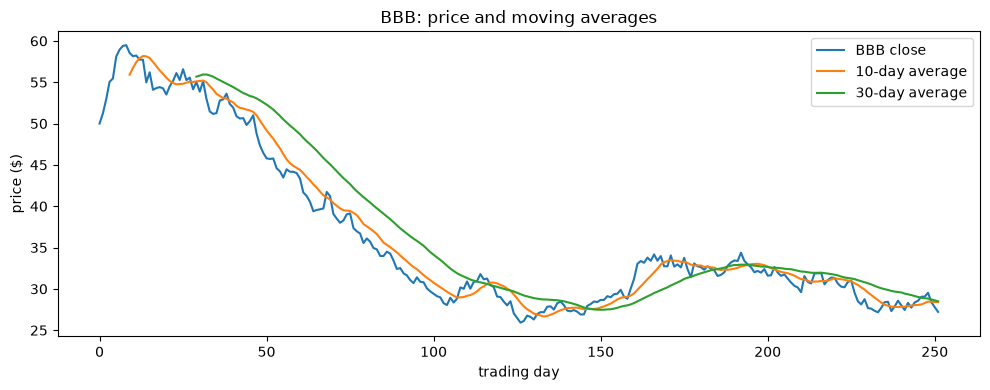

In [120]:
days = np.arange(n_days)                 # x-axis: trading day number, 0 to 251
bbb = prices[:, 1]                       # BBB closing prices

# Task 15.1a: the two moving averages for BBB, as NumPy arrays (window lengths are in params)
sma_short = np.array(tt.simple_moving_average(bbb, params["short_window"]))
sma_long = np.array(tt.simple_moving_average(bbb, params["long_window"]))

# Task 15.1b: plot the price and both averages. Add a title, axis labels, and a legend.
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(days, bbb, label="BBB close")
ax.plot(days, sma_short, label="%d-day average" % params["short_window"])
ax.plot(days, sma_long, label="%d-day average" % params["long_window"])
ax.set_title("BBB: price and moving averages")
ax.set_xlabel("trading day")
ax.set_ylabel("price ($)")
ax.legend()
fig.tight_layout()
fig.savefig("output/bbb_price_and_sma.png", dpi=150)
plt.show()

In [121]:
assert sma_short.shape == (n_days,) and np.isnan(sma_short[0]), "sma_short should have one value per day, starting with NaN"
assert os.path.exists("output/bbb_price_and_sma.png"), "save the chart to output/bbb_price_and_sma.png"
print("✅ Task 15.1 passed")

✅ Task 15.1 passed


### Task 15.2 · One panel per ticker
`plt.subplots(nrows=1, ncols=3)` returns three axes in `axes`. Loop over them with `enumerate` so you know which ticker each axis is for.

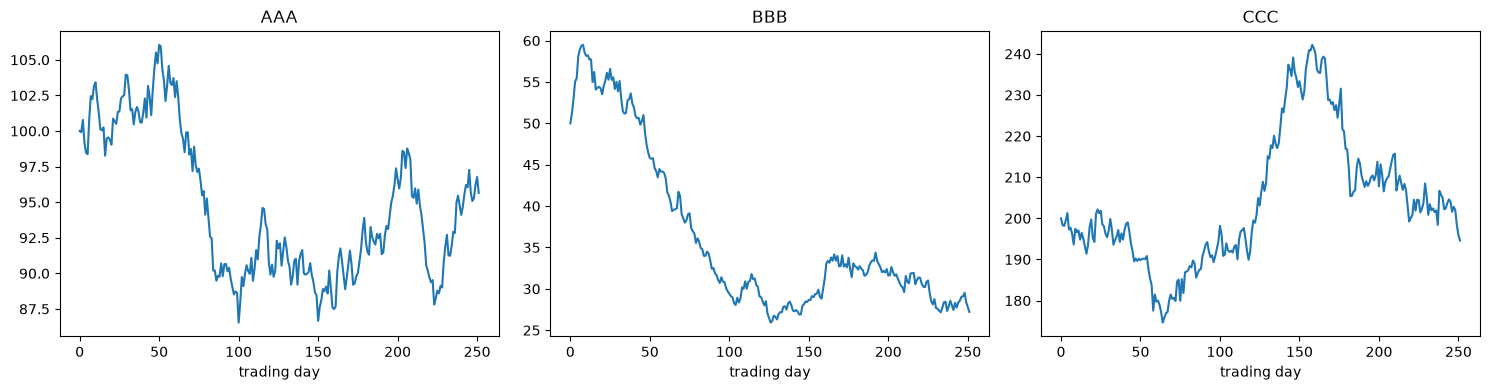

In [122]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
# Task 15.2: for each axis, plot that ticker's prices, set the title to the ticker name, and label the x-axis
for i, ax in enumerate(axes):
    ax.plot(days, prices[:, i])
    ax.set_title(TICKERS[i])
    ax.set_xlabel("trading day")
fig.tight_layout()
plt.show()

In [123]:
assert axes[0].get_title() == "AAA" and axes[2].get_title() == "CCC", "each panel's title should be its ticker"
assert len(axes[1].lines) == 1, "each panel should have exactly one line"
print("✅ Task 15.2 passed")

✅ Task 15.2 passed


### Task 16.1 · Write `run_backtest`
The function is complete. The explanation of each step is in the comments.

In [124]:
def run_backtest(ticker, closes, params):
    """Run the moving-average crossover on one ticker's closing prices.

    Returns a dict with: equity (NumPy array, one value per day), trades (list of
    (day, side, shares, price) tuples), final_value, total_return, max_drawdown, n_trades.
    """
    n = len(closes)
    fee = params["fee"]

    # Step 1: the moving averages for every day (lists, with NaN at the start)
    short_sma = tt.simple_moving_average(closes, params["short_window"])
    long_sma = tt.simple_moving_average(closes, params["long_window"])

    # Step 2: a new account, an equity list that starts with the starting cash, and an empty trade list
    pf = tt.Portfolio(params["initial_cash"])
    equity = [params["initial_cash"]]
    trades = []

    # Step 3: go through days 0 to n-2. The last day cannot be traded, because fills happen at t + 1.
    for t in range(n - 1):
        fill_price = closes[t + 1]           # trades fill at the next day's close
        held = pf.holdings.get(ticker, 0)    # shares we own right now

        # Step 3a (entry): if the short average is above the long average and we hold nothing,
        #   buy as many whole shares as we can afford (tt.position_size), and record the trade.
        # Step 3b (exit): if the short average is at or below the long average and we hold shares,
        #   sell all of them, and record the trade.
        # Note: a comparison with NaN is False, so nothing happens before the long average exists.
        if short_sma[t] > long_sma[t] and held == 0:
            shares = tt.position_size(pf.cash, fill_price, fee)
            if shares > 0:
                pf.buy(ticker, fill_price, shares, fee)
                trades.append((t + 1, "BUY", shares, fill_price))
        elif short_sma[t] <= long_sma[t] and held > 0:
            pf.sell(ticker, fill_price, held, fee)
            trades.append((t + 1, "SELL", held, fill_price))

        # Step 3c: record today's equity, valued at the fill price
        equity.append(pf.total_value({ticker: fill_price}))

    # Step 4: the summary numbers
    final_value = equity[-1]
    return {
        "equity": np.array(equity),
        "trades": trades,
        "final_value": final_value,
        "total_return": tt.total_return(params["initial_cash"], final_value),
        "max_drawdown": tt.max_drawdown(equity),
        "n_trades": len(trades),
    }

In [125]:
_res = run_backtest("BBB", prices[:, 1], params)
assert isinstance(_res, dict), "run_backtest should return a dict"
assert set(_res.keys()) == {"equity", "trades", "final_value", "total_return", "max_drawdown", "n_trades"}, "the dict should have the six keys listed in the docstring"
assert len(_res["equity"]) == n_days and _res["equity"][0] == params["initial_cash"], "equity should start at the starting cash and have one value per day"
assert _res["n_trades"] == len(_res["trades"]), "n_trades should equal the number of trades"
assert all(tr[0] >= params["long_window"] for tr in _res["trades"]), "no trade may happen before the long average exists"
assert all(tr[2] > 0 for tr in _res["trades"]), "every trade should have a positive number of shares"
assert all(tr[3] == prices[tr[0], 1] for tr in _res["trades"]), "each trade should fill at the closing price of the day it is recorded on"
print("✅ Task 16.1 passed")

✅ Task 16.1 passed


### Task 16.2 · Run all three tickers and summarize

In [126]:
results = {}                             # ticker -> the dict returned by run_backtest
# Task 16.2a: loop over TICKERS with enumerate. Column i of prices holds ticker i.
for i, name in enumerate(TICKERS):
    results[name] = run_backtest(name, prices[:, i], params)

# Task 16.2b: build one line of text per ticker and add it to summary_lines
summary_lines = []
for name in TICKERS:
    r = results[name]
    summary_lines.append("%-4s final %10.2f | return %+7.2f%% | max drawdown %7.2f%% | trades %3d" % (
        name, r["final_value"], 100 * r["total_return"], 100 * r["max_drawdown"], r["n_trades"]))

print("ticker | final value | return | max drawdown | trades")
for line in summary_lines:
    print(line)

ticker | final value | return | max drawdown | trades
AAA  final    9594.00 | return   -4.06% | max drawdown   -9.01% | trades   9
BBB  final   10144.74 | return   +1.45% | max drawdown  -10.74% | trades   6
CCC  final   10944.68 | return   +9.45% | max drawdown  -15.23% | trades   8


In [127]:
assert set(results.keys()) == set(TICKERS), "results should have one entry per ticker"
assert [results[t]["n_trades"] for t in TICKERS] == [9, 6, 8], "with the rules above the trade counts should be 9, 6 and 8"
assert abs(results["BBB"]["final_value"] - 10144.74) < 0.01, "the BBB final value should be about 10144.74"
assert len(summary_lines) == 3 and all("%" in line for line in summary_lines), "summary_lines should hold one text line per ticker"
print("✅ Task 16.2 passed")

✅ Task 16.2 passed


### Task 16.3 · Buy and hold, for comparison
Buy and hold means investing all the starting cash on day 0 and never selling. For this simple benchmark, ignore fees and whole shares.

`params["initial_cash"] * prices / prices[0]` works for all three tickers at once. NumPy **broadcasts** the one row `prices[0]` across every row of `prices`.

In [128]:
# Task 16.3a: buy_hold[t, i] = initial_cash * prices[t, i] / prices[0, i]
buy_hold = params["initial_cash"] * prices / prices[0]

# Task 16.3b: the final buy-and-hold return for each ticker, as a decimal
bh_return = buy_hold[-1] / params["initial_cash"] - 1
print("buy & hold returns (%):", np.round(bh_return * 100, 2))

buy & hold returns (%): [ -4.35 -45.56  -2.7 ]


In [129]:
assert buy_hold.shape == prices.shape and np.allclose(buy_hold[0], params["initial_cash"]), "day 0 of buy_hold should equal the starting cash for every ticker"
assert bh_return.shape == (3,) and np.allclose(bh_return * 100, [-4.35, -45.56, -2.70], atol=0.01), "buy & hold returns should be about -4.35%, -45.56% and -2.70%"
print("✅ Task 16.3 passed")

✅ Task 16.3 passed


### Task 16.4 · Compare the results, then save the equity curves
Compare each ticker's strategy return with its buy-and-hold return. Then save the equity curves to a CSV file with one column per ticker.

<details><summary><b>💡 Hint</b></summary>

`np.array([results[name]["equity"] for name in TICKERS])` has one row per ticker. Add `.T` to turn it into one row per day.

`",".join(TICKERS)` joins the names into `"AAA,BBB,CCC"`. It is the header for the CSV file.

</details>

In [130]:
# Task 16.4a: print one comparison line per ticker
for i, name in enumerate(TICKERS):
    print("%s: strategy %+.2f%% vs buy & hold %+.2f%%" % (name, 100 * results[name]["total_return"], 100 * bh_return[i]))

# Task 16.4b: the equity curves as one array with shape (days, tickers)
equity_table = np.array([results[name]["equity"] for name in TICKERS]).T
np.savetxt("output/equity_curves.csv", equity_table, delimiter=",", header=",".join(TICKERS), comments="")
print("saved output/equity_curves.csv with shape", equity_table.shape)

AAA: strategy -4.06% vs buy & hold -4.35%
BBB: strategy +1.45% vs buy & hold -45.56%
CCC: strategy +9.45% vs buy & hold -2.70%
saved output/equity_curves.csv with shape (252, 3)


In [131]:
assert equity_table.shape == (n_days, 3), "equity_table should have one row per day and one column per ticker"
assert np.genfromtxt("output/equity_curves.csv", delimiter=",", skip_header=1).shape == (n_days, 3), "the saved CSV should have n_days rows and 3 columns"
print("✅ Task 16.4 passed")

✅ Task 16.4 passed


### Task 16.5 · Plot strategy against buy and hold
For each ticker, draw the strategy equity as a solid line and buy and hold as a dashed line (`linestyle="--"`). Give each line a label.

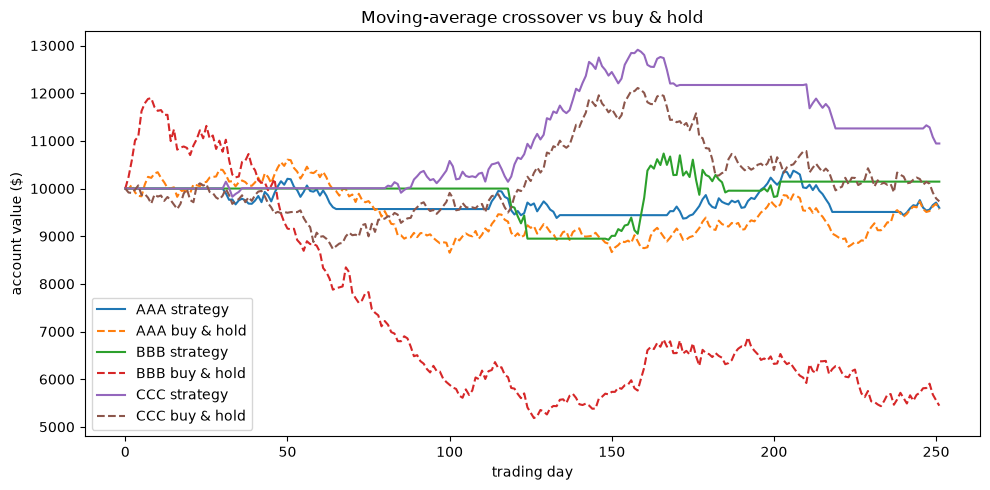

In [132]:
fig, ax = plt.subplots(figsize=(10, 5))
# Task 16.5: for each ticker, plot the strategy and buy & hold lines against days
for i, name in enumerate(TICKERS):
    ax.plot(days, results[name]["equity"], label=name + " strategy")
    ax.plot(days, buy_hold[:, i], linestyle="--", label=name + " buy & hold")
ax.set_title("Moving-average crossover vs buy & hold")
ax.set_xlabel("trading day")
ax.set_ylabel("account value ($)")
ax.legend()
fig.tight_layout()
fig.savefig("output/equity_curves.png", dpi=150)
plt.show()

In [133]:
assert len(ax.lines) == 6, "plot two lines per ticker (strategy and buy & hold), 6 lines in total"
assert os.path.exists("output/equity_curves.png"), "save the chart to output/equity_curves.png"
print("✅ Task 16.5 passed")

✅ Task 16.5 passed


### Task 16.6 · Parameter sweep: nested loops and tuple keys
Try three pairs of windows: (5, 20), (10, 30), and (20, 50). For each ticker and pair, store the total return in `sweep` under the key `(ticker, short, long)`. Use a copy of `params`, so the original stays unchanged.

<details><summary><b>💡 Hint</b></summary>

`trial = params.copy()` makes a copy of the dictionary. Set `trial["short_window"]` and `trial["long_window"]`, then loop over the tickers and call `run_backtest(name, prices[:, i], trial)`.

</details>

In [134]:
sweep = {}
for short_w, long_w in [(5, 20), (10, 30), (20, 50)]:
    trial = params.copy()                 # a copy, so params itself is not changed
    trial["short_window"] = short_w
    trial["long_window"] = long_w
    for i, name in enumerate(TICKERS):
        result = run_backtest(name, prices[:, i], trial)
        sweep[(name, short_w, long_w)] = result["total_return"]

for key in sweep:
    print(key, "%+.2f%%" % (100 * sweep[key]))
print("params still uses", params["short_window"], "and", params["long_window"])

('AAA', 5, 20) +12.27%
('BBB', 5, 20) -10.65%
('CCC', 5, 20) +8.04%
('AAA', 10, 30) -4.06%
('BBB', 10, 30) +1.45%
('CCC', 10, 30) +9.45%
('AAA', 20, 50) -15.82%
('BBB', 20, 50) -6.85%
('CCC', 20, 50) +9.48%
params still uses 10 and 30


In [135]:
assert len(sweep) == 9, "sweep should have 3 tickers x 3 window pairs = 9 entries"
assert abs(sweep[("AAA", 10, 30)] - results["AAA"]["total_return"]) < 1e-12, "the (AAA, 10, 30) entry should match the main run"
assert params["short_window"] == 10 and params["long_window"] == 30, "params should not change during the sweep"
print("✅ Task 16.6 passed")

✅ Task 16.6 passed


### Task 16.7 · Reflect

**Answers**

1. **Next-day fills.** The signal uses the close of day *t*. If the trade filled at that same close, the backtest would act on a price that was only known after the decision was made, which is look-ahead bias. The results would look better than anything you could trade in practice. The rule *t + 1* removes this bias. Even so, a real trade may fill at a different price.

2. **Main run (10, 30).** The strategy returned −4.06% for AAA (buy and hold −4.35%), +1.45% for BBB (buy and hold −45.56%), and +9.45% for CCC (buy and hold −2.70%). It beat buy and hold on all three tickers, but the gap for AAA is small (0.29 percentage points). Buy and hold is only a simple reference: it ignores fees and whole shares. One simulated year and three tickers are not enough to show that the strategy works. Each result depends on the random path that ticker happened to follow. A real test needs many years, many markets, and results on data the strategy was not tuned on.

3. **The sweep.** Yes. With (5, 20), AAA returns +12.27% and BBB returns −10.65%. With (10, 30), AAA returns −4.06% and BBB returns +1.45%. The best window pair changes from one ticker to another. If you choose the windows that did best on the past data, you are overfitting: the result depends on the sample and will probably not hold on new data. Test parameters on data you did not use to choose them (walk-forward testing, Syllabus section 5).

4. **Higher fees.** With `fee = 5.0` every trade costs more, so each return falls a little. For example, CCC falls from +9.45% to +9.13%, and the number of trades stays the same. Fees matter more for strategies that trade often, because each trade pays the fee again.

## Part 17 · Wrap-up

### Self-check
Tick off what you can now do:
- [ ] Create variables, convert types, and use operators (Parts 1–2)
- [ ] Slice strings and format text (Part 3)
- [ ] Change lists, and use tuples and dictionaries (Parts 4–5)
- [ ] Write `if` / `elif` / `else`, `for`, `while`, and list comprehensions (Parts 6–7)
- [ ] Write functions with docstrings, default and keyword arguments, `lambda`, and `map` (Part 8)
- [ ] Write a class with `__init__`, methods, and `__str__` (Part 9)
- [ ] Raise and catch exceptions (Part 10)
- [ ] Write, import, and inspect a module, and use `math` and `os` (Part 11)
- [ ] Create and inspect NumPy arrays (Part 12)
- [ ] Load CSV data, handle missing values, and save and load `.npy` files (Part 13)
- [ ] Use indexing, masks, `axis`, `where`, and vectorized math (Part 14)
- [ ] Make charts with the object-oriented matplotlib API (Part 15)
- [ ] Backtest a strategy and explain its limits (Part 16)

### Stretch goals
1. Run the strategy with the Lecture 07 windows (`short_window=40`, `long_window=100`) and compare the results.
2. Add a stop-loss: sell when the price falls 10% below the entry price.
3. Replace the loop in `simple_moving_average` with a vectorized version (hint: `np.convolve`).
4. Compute the maximum drawdown without a loop (hint: `np.maximum.accumulate`).
5. Add a second strategy, such as "buy when the price is above its 20-day average", and compare the two.
6. **Next step:** Lecture 01 (Data Handling) loads real prices with pandas. Replace the simulated CSV with real data and run the backtest again.

When you are done, choose **Kernel → Restart & Run All**. If the notebook finishes without errors, the project is complete.